<a href="https://colab.research.google.com/github/JSJeong-me/Hair/blob/main/HairStyle_Model_Eval_Vector_Similarity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!cp /content/drive/MyDrive/digiclau_lab/images/GAIL/*.png /content/

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Embedding Images

In [1]:
import tensorflow as tf
import tensorflow_hub as hub
from PIL import Image
import numpy as np

In [2]:
model_url = "https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2"

IMAGE_SHAPE = (224, 224)

layer = hub.KerasLayer(model_url)
model = tf.keras.Sequential([layer])

In [3]:
def extract(file):
  file = Image.open(file).convert('L').resize(IMAGE_SHAPE)
  display(file)

  file = np.stack((file,)*3, axis=-1)

  file = np.array(file)/255.0

  embedding = model.predict(file[np.newaxis, ...])
  #print(embedding)
  vgg16_feature_np = np.array(embedding)
  flattended_feature = vgg16_feature_np.flatten()

  #print(len(flattended_feature))
  #print(flattended_feature)
  #print('-----------')
  return flattended_feature

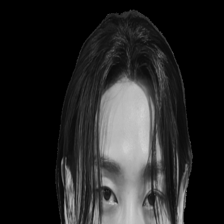

1/1 [==============================] - 3s 3s/step


/usr/local/lib/python3.10/dist-packages/PIL/Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


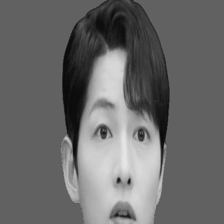

1/1 [==============================] - 0s 34ms/step


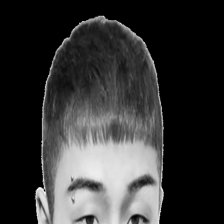

1/1 [==============================] - 0s 34ms/step


In [4]:
JUMP_base = extract('JUMP-upper.png')
GAIL_base = extract('GAIL-upper.png')
CROP_base = extract('CROP-upper.png')

In [ ]:
# ail1 = extract('upper_jump(91).png')
# crop_base = extract('CROP-upper.png')

# Distances Images

In [5]:
from scipy.spatial import distance

In [6]:
metric = 'dice'

In [14]:
import pandas as pd

# 파일 경로 설정
file_path = 'png_file_list.xlsx'

# 엑셀 파일 불러오기
df = pd.read_excel(file_path)

# 1~30 행까지 첫 번째 열의 데이터 읽어오기

first_column_data_with_loop = []

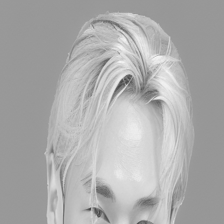

1/1 [==============================] - 0s 39ms/step


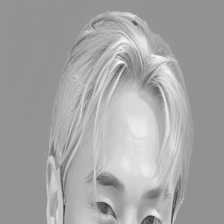

1/1 [==============================] - 0s 31ms/step


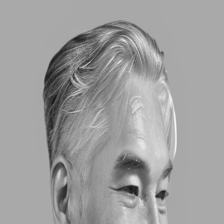

1/1 [==============================] - 0s 38ms/step


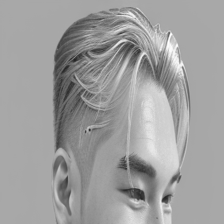

1/1 [==============================] - 0s 39ms/step


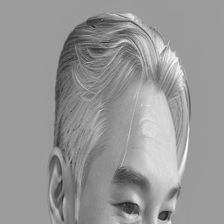

1/1 [==============================] - 0s 32ms/step


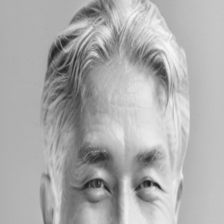

1/1 [==============================] - 0s 35ms/step


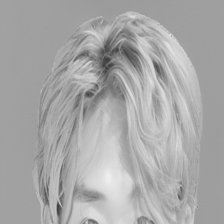

1/1 [==============================] - 0s 32ms/step


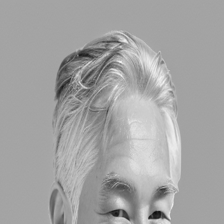

1/1 [==============================] - 0s 31ms/step


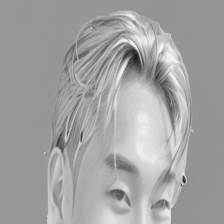

1/1 [==============================] - 0s 31ms/step


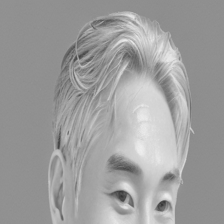

1/1 [==============================] - 0s 51ms/step


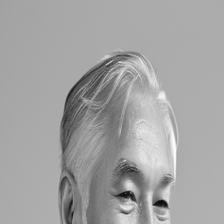

1/1 [==============================] - 0s 32ms/step


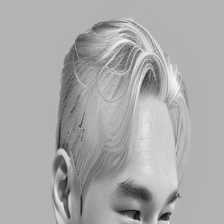

1/1 [==============================] - 0s 31ms/step


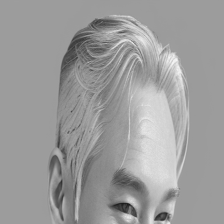

1/1 [==============================] - 0s 32ms/step


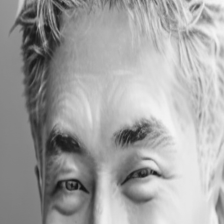

1/1 [==============================] - 0s 33ms/step


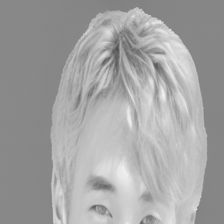

1/1 [==============================] - 0s 32ms/step


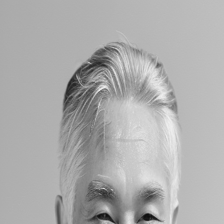

1/1 [==============================] - 0s 29ms/step


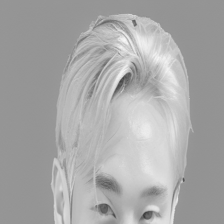

1/1 [==============================] - 0s 31ms/step


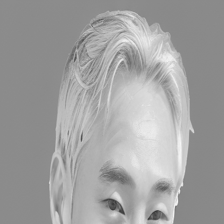

1/1 [==============================] - 0s 35ms/step


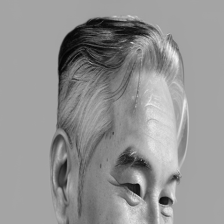

1/1 [==============================] - 0s 37ms/step


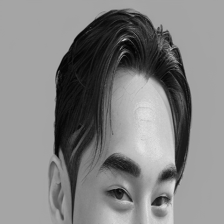

1/1 [==============================] - 0s 45ms/step


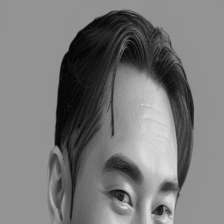

1/1 [==============================] - 0s 36ms/step


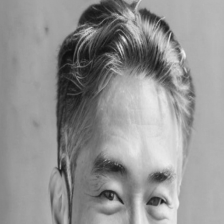

1/1 [==============================] - 0s 32ms/step


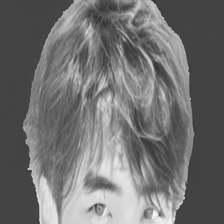

1/1 [==============================] - 0s 37ms/step


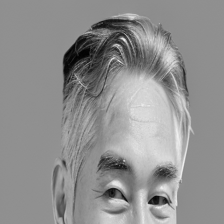

1/1 [==============================] - 0s 32ms/step


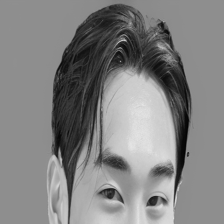

1/1 [==============================] - 0s 31ms/step


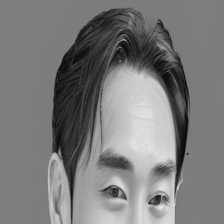

1/1 [==============================] - 0s 36ms/step


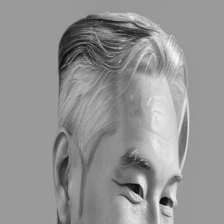

1/1 [==============================] - 0s 21ms/step


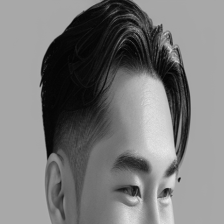

1/1 [==============================] - 0s 20ms/step


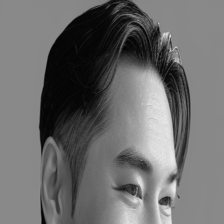

1/1 [==============================] - 0s 22ms/step


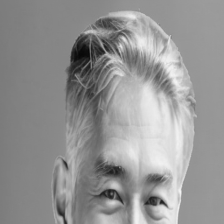

1/1 [==============================] - 0s 31ms/step


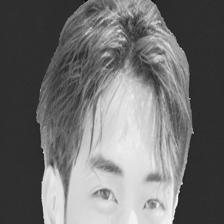

1/1 [==============================] - 0s 22ms/step


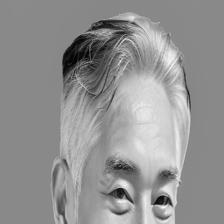

1/1 [==============================] - 0s 21ms/step


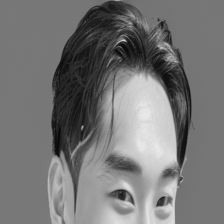

1/1 [==============================] - 0s 21ms/step


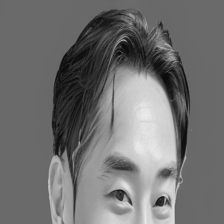

1/1 [==============================] - 0s 21ms/step


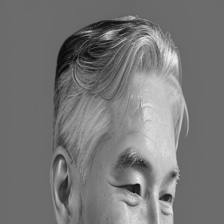

1/1 [==============================] - 0s 21ms/step


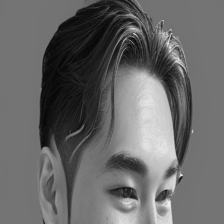

1/1 [==============================] - 0s 24ms/step


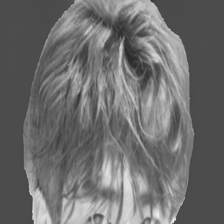

1/1 [==============================] - 0s 23ms/step


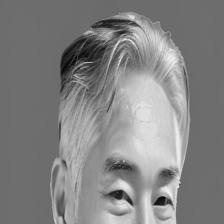

1/1 [==============================] - 0s 21ms/step


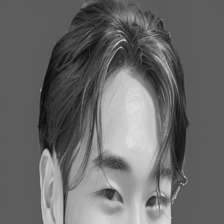

1/1 [==============================] - 0s 28ms/step


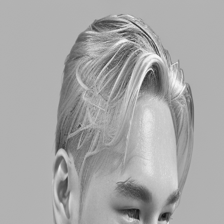

1/1 [==============================] - 0s 20ms/step


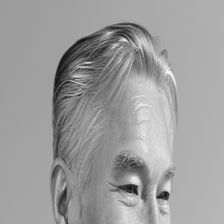

1/1 [==============================] - 0s 22ms/step


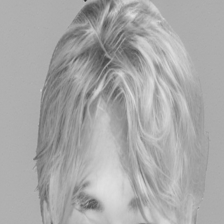

1/1 [==============================] - 0s 21ms/step


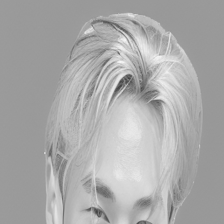

1/1 [==============================] - 0s 21ms/step


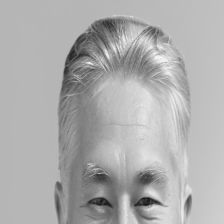

1/1 [==============================] - 0s 20ms/step


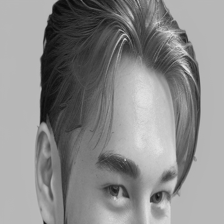

1/1 [==============================] - 0s 21ms/step


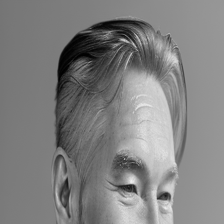

1/1 [==============================] - 0s 24ms/step


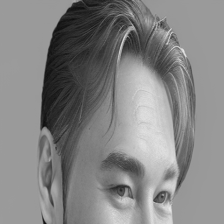

1/1 [==============================] - 0s 21ms/step


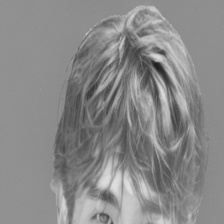

1/1 [==============================] - 0s 22ms/step


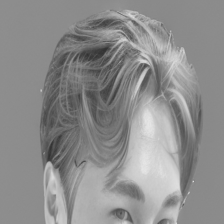

1/1 [==============================] - 0s 22ms/step


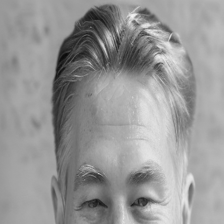

1/1 [==============================] - 0s 20ms/step


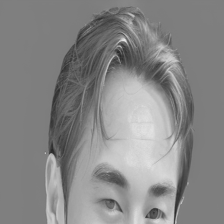

1/1 [==============================] - 0s 27ms/step


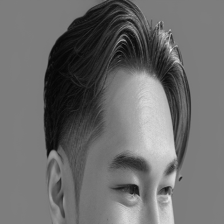

1/1 [==============================] - 0s 24ms/step


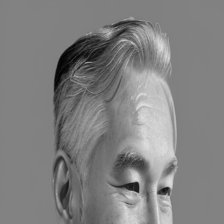

1/1 [==============================] - 0s 23ms/step


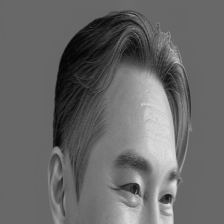

1/1 [==============================] - 0s 23ms/step


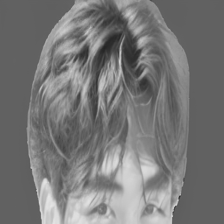

1/1 [==============================] - 0s 20ms/step


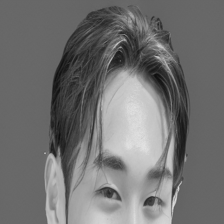

1/1 [==============================] - 0s 27ms/step


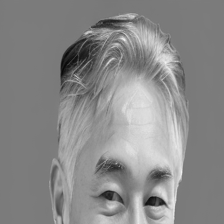

1/1 [==============================] - 0s 27ms/step


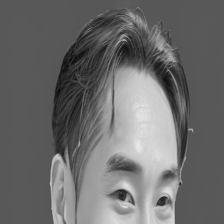

1/1 [==============================] - 0s 28ms/step


In [15]:
for i in range(61, 119):
  first_column_data = df.iloc[i, 0]
  CROP = extract(first_column_data)
  first_column_data_with_loop.append(distance.cdist([JUMP_base], [CROP], metric)[0])
  # print(dc)
  # print("the distance between CROP and the Hair Style is {}".format(dc))


In [16]:
# first_column_data_with_loop 값을 새로운 엑셀 파일에 저장
output_file_path = 'first_column_data_with_loop.xlsx'

# DataFrame 생성
df_output = pd.DataFrame({'First_Column': first_column_data_with_loop})

# 엑셀 파일로 저장
df_output.to_excel(output_file_path, index=False)

output_file_path


'first_column_data_with_loop.xlsx'

In [ ]:
dc = distance.cdist([base], [ail1], metric)[0]
print(dc)
print("the distance between Base and the Hair Style is {}".format(dc))

[0.29963584]
the distance between cat1 and the cat2 is [0.29963584]


In [ ]:
# dc = distance.cdist([ail_base], [crop_base], metric)[0]
# print(dc)
# print("the distance between cat1 and the rocket is {}".format(dc))

In [ ]:
# dc = distance.cdist([ail1], [crop_base], metric)[0]
# print(dc)
# print("the distance cat2 original and the rocket is {}".format(dc))